# 04b — Amazon Baselines

**input:** `data/amazon/items.pkl`, `data/amazon/embeddings.npy`, `data/amazon/results_ours.pkl`

Same baselines as notebook 04 — applied to Amazon Clothing.

**output:** `data/amazon/results_random.pkl`, `data/amazon/results_taxonomy.pkl`

In [12]:
import numpy as np
import pandas as pd
import pickle, sys
from pathlib import Path
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append(str(Path('../')))
from query_templates_amazon import get_query_for_item

DATA_DIR    = Path('../data/amazon')
RESULTS_DIR = Path('../results')

items      = pd.read_pickle(DATA_DIR / 'items.pkl')
embeddings = np.load(DATA_DIR / 'embeddings.npy')
sbert      = SentenceTransformer('all-MiniLM-L6-v2')

with open(DATA_DIR / 'results_ours.pkl', 'rb') as f:
    ours = pickle.load(f)
df_ours      = ours['df']
target_items = ours['target_items']

STOP_SIZE = 5
MAX_TURNS = 6
TOP_N     = 500

np.random.seed(42)
print(f'Targets: {len(target_items)}')
print('imports OK')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Targets: 200
imports OK


### Shared helper functions

In [13]:
import sys
sys.path.insert(0, '../src')

from core import (
    entropy,
    expected_entropy,
    information_gain,
    adaptive_k,
    simulated_user,
    retrieve
)
def make_query_embedding(target_idx):
    cat  = items.iloc[target_idx]['category']
    q    = get_query_for_item(cat)
    emb  = sbert.encode(q, normalize_embeddings=True)
    return emb


print('functions OK')

functions OK


### Baseline 1 — Random

In [14]:
def random_partition(C, k):
    s = C.copy(); np.random.shuffle(s)
    return [list(c) for c in np.array_split(s, k) if len(c) > 0]

def run_random(target_idx):
    q_emb = make_query_embedding(target_idx)
    C = retrieve(q_emb,embeddings, TOP_N)
    if target_idx not in C: C.append(target_idx)
    entropy_trace = [entropy(C)]; ig_trace = []; turn = 0
    while len(C) > STOP_SIZE and turn < MAX_TURNS:
        k = adaptive_k(len(C))
        p = random_partition(C, k)
        ig_trace.append(information_gain(C, p))
        C = p[simulated_user(p, target_idx)]
        turn += 1; entropy_trace.append(entropy(C))
    return {'turns': turn, 'final_size': len(C), 'success': target_idx in C,
            'entropy_trace': entropy_trace, 'ig_trace': ig_trace}

results_random = []
for t in tqdm(target_items, desc='Random'):
    r = run_random(int(t)); r['target_idx'] = int(t)
    results_random.append(r)
df_random = pd.DataFrame(results_random)
print(f'Avg turns: {df_random["turns"].mean():.2f}  |  Final size: {df_random["final_size"].mean():.2f}  |  Success: {df_random["success"].mean():.3f}')

Random: 100%|██████████| 200/200 [00:04<00:00, 42.90it/s]

Avg turns: 4.00  |  Final size: 4.07  |  Success: 1.000


### Baseline 2 — Taxonomy (category-based)

In [15]:
    # primary category = last segment of the category string
item_primary_cat = items['category'].str.split('>').str[-1].str.strip().values

def taxonomy_partition(C):
    groups = {}
    for idx in C:
        cat = item_primary_cat[idx]
        groups.setdefault(cat, []).append(idx)
    partition = [g for g in groups.values() if g]
    if len(partition) > 6:
        partition = sorted(partition, key=len, reverse=True)[:6]
    return partition

def run_taxonomy(target_idx):
    q_emb = make_query_embedding(target_idx)
    C = retrieve(q_emb,embeddings, TOP_N)
    if target_idx not in C: C.append(target_idx)
    entropy_trace = [entropy(C)]; ig_trace = []; turn = 0
    while len(C) > STOP_SIZE and turn < MAX_TURNS:
        p = taxonomy_partition(C)
        if len(p) <= 1: break
        ig_trace.append(information_gain(C, p))
        C = p[simulated_user(p, target_idx)]
        turn += 1; entropy_trace.append(entropy(C))
    return {'turns': turn, 'final_size': len(C), 'success': target_idx in C,
            'entropy_trace': entropy_trace, 'ig_trace': ig_trace}

results_taxonomy = []
for t in tqdm(target_items, desc='Taxonomy'):
    r = run_taxonomy(int(t)); r['target_idx'] = int(t)
    results_taxonomy.append(r)
df_taxonomy = pd.DataFrame(results_taxonomy)
print(f'Avg turns: {df_taxonomy["turns"].mean():.2f}  |  Final size: {df_taxonomy["final_size"].mean():.2f}  |  Success: {df_taxonomy["success"].mean():.3f}')

Taxonomy: 100%|██████████| 200/200 [00:05<00:00, 36.83it/s]

Avg turns: 1.00  |  Final size: 57.13  |  Success: 0.325


### Comparison + Plot

Candidate set size after K turns (lower = better):
 Turns    Semantic    Taxonomy      Random
------------------------------------------
     1       110.9        57.1       100.2
     2        29.7        57.1        24.1
     3        10.7        57.1         8.0
     4         5.3        57.1         4.1
     5         3.7        57.1         4.1
     6         3.3        57.1         4.1


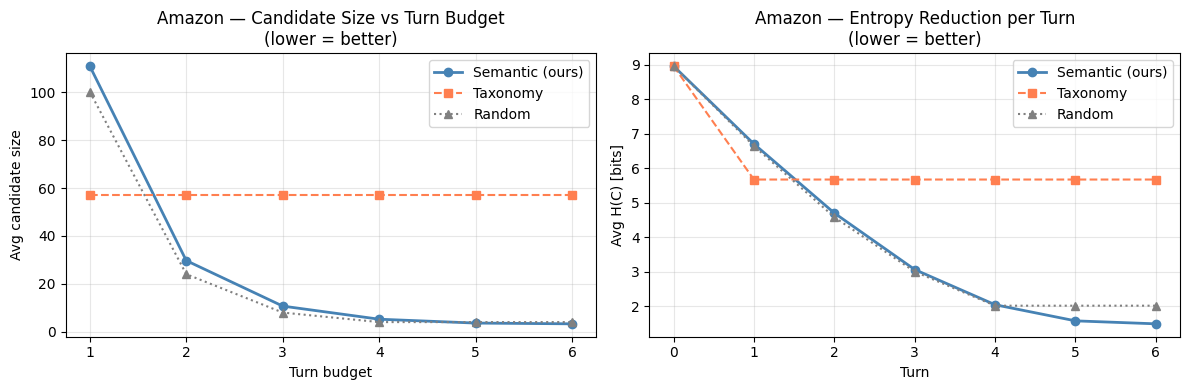

Saved.
✅ notebook 04b complete


In [16]:
def size_at_turn(df_results, turn_k):
    sizes = []
    for _, row in df_results.iterrows():
        trace = row['entropy_trace']
        sizes.append(2**trace[turn_k] if len(trace) > turn_k else row['final_size'])
    return np.mean(sizes)

def mean_entropy_trace(df_results, max_turns):
    traces = df_results['entropy_trace'].tolist()
    padded = [t + [t[-1]] * (max_turns + 1 - len(t)) for t in traces]
    return np.mean(padded, axis=0)

# Summary table
print('Candidate set size after K turns (lower = better):')
print(f'{"Turns":>6}  {"Semantic":>10}  {"Taxonomy":>10}  {"Random":>10}')
print('-' * 42)
for k in range(1, MAX_TURNS + 1):
    print(f'{k:>6}  {size_at_turn(df_ours, k):>10.1f}  {size_at_turn(df_taxonomy, k):>10.1f}  {size_at_turn(df_random, k):>10.1f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
k_range = range(1, MAX_TURNS + 1)

axes[0].plot(k_range, [size_at_turn(df_ours, k) for k in k_range],     marker='o', color='steelblue', label='Semantic (ours)', linewidth=2)
axes[0].plot(k_range, [size_at_turn(df_taxonomy, k) for k in k_range], marker='s', color='coral',     label='Taxonomy', linestyle='--')
axes[0].plot(k_range, [size_at_turn(df_random, k) for k in k_range],   marker='^', color='gray',      label='Random',   linestyle=':')
axes[0].set_xlabel('Turn budget'); axes[0].set_ylabel('Avg candidate size')
axes[0].set_title('Amazon — Candidate Size vs Turn Budget\n(lower = better)')
axes[0].legend(); axes[0].grid(alpha=0.3)

our_h  = mean_entropy_trace(df_ours, MAX_TURNS)
tax_h  = mean_entropy_trace(df_taxonomy, MAX_TURNS)
rand_h = mean_entropy_trace(df_random, MAX_TURNS)
x = range(len(our_h))
axes[1].plot(x, our_h,  marker='o', color='steelblue', label='Semantic (ours)', linewidth=2)
axes[1].plot(x, tax_h,  marker='s', color='coral',     label='Taxonomy', linestyle='--')
axes[1].plot(x, rand_h, marker='^', color='gray',      label='Random',   linestyle=':')
axes[1].set_xlabel('Turn'); axes[1].set_ylabel('Avg H(C) [bits]')
axes[1].set_title('Amazon — Entropy Reduction per Turn\n(lower = better)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'amazon_comparison.png', dpi=150)
plt.show()

with open(DATA_DIR / 'results_random.pkl', 'wb') as f:
    pickle.dump({'df': df_random}, f)
with open(DATA_DIR / 'results_taxonomy.pkl', 'wb') as f:
    pickle.dump({'df': df_taxonomy}, f)

print('Saved.')
print('✅ notebook 04b complete')